In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from utils.cleaning import *
from utils.outlier import *
from utils.stats import *
from ETL_Pipeline import *
from utils.config import *
from utils.db import *
from utils.visual import *


# OVERVIEW

User Logs

In [2]:
files = ['kkbox-dataset/user_logs.csv', 'kkbox-dataset/user_logs_v2.csv']

all_chunks = []
for file_name, idx, chunk in extract(files):
    # Ép kiểu dữ liệu ngay từng khối để giải phóng bớt 60% RAM trước khi concat
    chunk_opt = optimize_dtypes(chunk)
    all_chunks.append(chunk_opt)

# Ghép toàn bộ các khối lại thành một DataFrame duy nhất chứa 100% dữ liệu
df_user_logs = pd.concat(all_chunks, ignore_index=True)
del all_chunks

In [3]:
import gc
import pandas as pd

# Giả sử df_user_logs hiện tại đang có ~38.3 triệu dòng
current_rows = len(df_user_logs)
target_rows = 20_000_000

# 1. Tính toán tỷ lệ user cần lấy mẫu
frac = target_rows / current_rows  # ~ 0.52 (52% user)

print(f"Tổng số dòng hiện tại: {current_rows:,}")
print(f"Tỷ lệ user cần giữ lại: {frac:.2%}")

# 2. Lấy mẫu ngẫu nhiên theo danh sách msno duy nhất
unique_users = pd.Series(df_user_logs['msno'].unique())
sampled_users = set(unique_users.sample(frac=frac, random_state=42))
del unique_users

# 3. Lọc bảng user_logs theo tập user này
df_user_logs = df_user_logs[df_user_logs['msno'].isin(sampled_users)]
del sampled_users
gc.collect()

print(f"=> Số dòng sau khi giảm: {len(df_user_logs):,} dòng.")

Tổng số dòng hiện tại: 38,318,269
Tỷ lệ user cần giữ lại: 52.19%
=> Số dòng sau khi giảm: 19,969,581 dòng.


In [6]:
import pandas as pd

print("=" * 65)
print("--- BÁO CÁO KIỂM TOÁN TÍNH NGUYÊN VẸN TRỤC THỜI GIAN USER_LOGS ---")
print("=" * 65)

# Đảm bảo cột date ở định dạng datetime (nếu đang là int/str)
date_series = pd.to_datetime(df_user_logs['date'].astype('int32'), format='%Y%m%d') if df_user_logs['date'].dtype != '<M8[ns]' else df_user_logs['date']

# 1. Kiểm tra 2 mốc biên thời gian (Bắt đầu và Kết thúc)
min_date = date_series.min()
max_date = date_series.max()
unique_days = date_series.nunique()

print(f"1. Mốc thời gian bắt đầu (Min Date) : {min_date.strftime('%Y-%m-%d')}")
print(f"2. Mốc thời gian kết thúc (Max Date): {max_date.strftime('%Y-%m-%d')}")
print(f"3. Tổng số ngày duy nhất có dữ liệu  : {unique_days:,} ngày")

# 2. Thống kê phân bố dữ liệu theo từng tháng để kiểm tra tính liên tục
months_series = date_series.dt.strftime('%Y-%m')
monthly_counts = months_series.value_counts().sort_index().reset_index()
monthly_counts.columns = ['Năm_Tháng (YYYY-MM)', 'Số_Lượng_Log']

print("\n--- PHÂN PHỐI LƯỢT GHI THEO TỪNG THÁNG ---")
print(monthly_counts.to_string(index=False))
print("-" * 65)
print(f"=> Tổng số tháng được bảo toàn: {len(monthly_counts)} tháng")

--- BÁO CÁO KIỂM TOÁN TÍNH NGUYÊN VẸN TRỤC THỜI GIAN USER_LOGS ---
1. Mốc thời gian bắt đầu (Min Date) : 2015-01-01
2. Mốc thời gian kết thúc (Max Date): 2017-03-31
3. Tổng số ngày duy nhất có dữ liệu  : 821 ngày

--- PHÂN PHỐI LƯỢT GHI THEO TỪNG THÁNG ---
Năm_Tháng (YYYY-MM)  Số_Lượng_Log
            2015-01        341019
            2015-02        302091
            2015-03        349695
            2015-04        345852
            2015-05        355248
            2015-06        345867
            2015-07        346402
            2015-08        353873
            2015-09        357879
            2015-10        381621
            2015-11        380443
            2015-12        398137
            2016-01        398122
            2016-02        368209
            2016-03        423374
            2016-04        420502
            2016-05        437855
            2016-06        427708
            2016-07        439952
            2016-08        444609
            2016-09        43

In [4]:
df_user_logs.head()

,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,smUCRXP1KI/21kb8WnjocR4afdN5tjftVIlEzNIQpWA=,20160310,18,6,2,10,103,82,26546.240234
1,smUCRXP1KI/21kb8WnjocR4afdN5tjftVIlEzNIQpWA=,20160502,15,3,2,5,11,28,4030.010010
2,smUCRXP1KI/21kb8WnjocR4afdN5tjftVIlEzNIQpWA=,20160625,14,4,3,8,21,27,8380.596680
3,smUCRXP1KI/21kb8WnjocR4afdN5tjftVIlEzNIQpWA=,20160818,4,0,0,1,5,6,1591.318970
4,smUCRXP1KI/21kb8WnjocR4afdN5tjftVIlEzNIQpWA=,20161015,95,7,4,2,18,94,7218.014160


In [5]:
df_user_logs.info(show_counts = True)

<class 'pandas.DataFrame'>
Index: 19969581 entries, 0 to 38318263
Data columns (total 9 columns):
 #   Column      Non-Null Count     Dtype  
---  ------      --------------     -----  
 0   msno        19969581 non-null  str    
 1   date        19969581 non-null  int32  
 2   num_25      19969581 non-null  int16  
 3   num_50      19969581 non-null  int16  
 4   num_75      19969581 non-null  int16  
 5   num_985     19969581 non-null  int16  
 6   num_100     19969581 non-null  int32  
 7   num_unq     19969581 non-null  int16  
 8   total_secs  19969581 non-null  float32
dtypes: float32(1), int16(5), int32(2), str(1)
memory usage: 1.5 GB


In [5]:
print(quality_report(df_user_logs))

              dtype  missing  missing%    unique  \
column                                             
msno            str        0       0.0   1320097   
date          int32        0       0.0       821   
num_25        int16        0       0.0       963   
num_50        int16        0       0.0       424   
num_75        int16        0       0.0       250   
num_985       int16        0       0.0       356   
num_100       int32        0       0.0      1684   
num_unq       int16        0       0.0       948   
total_secs  float32        0       0.0  15992335   

                                                  sample  
column                                                    
msno        smUCRXP1KI/21kb8WnjocR4afdN5tjftVIlEzNIQpWA=  
date                                            20160310  
num_25                                                18  
num_50                                                 6  
num_75                                                 2  
num_985       

In [6]:
check_duplicates(df_user_logs, key_cols=['msno', 'date'])

Full duplicates    : OK
Key duplicates ['msno', 'date']: OK


In [7]:
total_plays = (
    df_user_logs['num_25'] + df_user_logs['num_50'] + 
    df_user_logs['num_75'] + df_user_logs['num_985'] + df_user_logs['num_100']
)
checks = {
    "total_secs < 0": df_user_logs['total_secs'] < 0,
    "total_secs > 86400 (hơn 24h)": df_user_logs['total_secs'] > 86400,
    "msno is null": df_user_logs['msno'].isnull(),
    "Có nghe nhạc nhưng total_secs = 0": (((df_user_logs['num_25'] + df_user_logs['num_100']) > 0) & (df_user_logs['total_secs'] == 0)),
    "num_unq > tổng bài hát đã nghe": df_user_logs['num_unq'] > total_plays
}
check_data_issues(df_user_logs, checks)

total_secs < 0                     : 3251 rows
total_secs > 86400 (hơn 24h)       : 11779 rows
msno is null                       : OK
Có nghe nhạc nhưng total_secs = 0  : OK
num_unq > tổng bài hát đã nghe     : OK


Transactions

In [8]:
files_transactions = ['kkbox-dataset/transactions.csv', 'kkbox-dataset/transactions_v2.csv']

all_chunks = []
for file_name, idx, chunk in extract(files_transactions):
    # Ép kiểu dữ liệu ngay từng khối để giải phóng bớt 60% RAM trước khi concat
    chunk_opt = optimize_dtypes(chunk)
    all_chunks.append(chunk_opt)

# Ghép toàn bộ các khối lại thành một DataFrame duy nhất chứa 100% dữ liệu
df_transactions = pd.concat(all_chunks, ignore_index=True)
del all_chunks

In [9]:
df_transactions.head()

,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,YyO+tlZtAXYXoZhNr3Vg3+dfVQvrBVGO8j1mfqe4ZHc=,41,30,129,129,1,20150930,20151101,0
1,AZtu6Wl0gPojrEQYB8Q3vBSmE2wnZ3hi1FbK1rQQ0A4=,41,30,149,149,1,20150930,20151031,0
2,UkDFI97Qb6+s2LWcijVVv4rMAsORbVDT2wNXF0aVbns=,41,30,129,129,1,20150930,20160427,0
3,M1C56ijxozNaGD0t2h68PnH2xtx5iO5iR2MVYQB6nBI=,39,30,149,149,1,20150930,20151128,0
4,yvj6zyBUaqdbUQSrKsrZ+xNDVM62knauSZJzakS9OW4=,39,30,149,149,1,20150930,20151121,0


In [10]:
df_transactions.info(show_counts = True)

<class 'pandas.DataFrame'>
RangeIndex: 22978755 entries, 0 to 22978754
Data columns (total 9 columns):
 #   Column                  Non-Null Count     Dtype
---  ------                  --------------     -----
 0   msno                    22978755 non-null  str  
 1   payment_method_id       22978755 non-null  int8 
 2   payment_plan_days       22978755 non-null  int16
 3   plan_list_price         22978755 non-null  int16
 4   actual_amount_paid      22978755 non-null  int16
 5   is_auto_renew           22978755 non-null  int8 
 6   transaction_date        22978755 non-null  int32
 7   membership_expire_date  22978755 non-null  int32
 8   is_cancel               22978755 non-null  int8 
dtypes: int16(3), int32(2), int8(3), str(1)
memory usage: 1.5 GB


In [11]:
print(quality_report(df_transactions))

                        dtype  missing  missing%   unique  \
column                                                      
msno                      str        0       0.0  2426143   
payment_method_id        int8        0       0.0       40   
payment_plan_days       int16        0       0.0       37   
plan_list_price         int16        0       0.0       55   
actual_amount_paid      int16        0       0.0       65   
is_auto_renew            int8        0       0.0        2   
transaction_date        int32        0       0.0      821   
membership_expire_date  int32        0       0.0     3473   
is_cancel                int8        0       0.0        2   

                                                              sample  
column                                                                
msno                    YyO+tlZtAXYXoZhNr3Vg3+dfVQvrBVGO8j1mfqe4ZHc=  
payment_method_id                                                 41  
payment_plan_days                           

In [12]:
check_duplicates(df_transactions, key_cols=['msno', 'transaction_date'])

Full duplicates    : 3339 rows
Key duplicates ['msno', 'transaction_date']: 326945 rows
                                                  msno  payment_method_id  payment_plan_days  plan_list_price  actual_amount_paid  is_auto_renew  transaction_date  membership_expire_date  is_cancel
5322301   ++0BJXY8tpirgIhJR14LDM1pnaRosjD1mdO1mIKxlJA=                 38                 30              149                 149              0          20150902                20151002          0
9815123   ++0BJXY8tpirgIhJR14LDM1pnaRosjD1mdO1mIKxlJA=                 35                  7                0                   0              0          20150902                20151012          0
7303282   ++2axpngZEynlxNr1+AkwgHHfaEZ/EeOj6Q284RiAkw=                 41                 30              149                 149              1          20160225                20160225          1
21055309  ++2axpngZEynlxNr1+AkwgHHfaEZ/EeOj6Q284RiAkw=                 35                  7                0           

In [13]:
transactions_date_dt = pd.to_datetime(df_transactions['transaction_date'].astype(str), format='%Y%m%d')
expire_date_dt = pd.to_datetime(df_transactions['membership_expire_date'].astype(str), format='%Y%m%d')

checks_transactions = {
    "Thiếu mã người dùng": (
        df_transactions['msno'].isnull()
    ),
    "Cước thực thu âm": (
        df_transactions['actual_amount_paid'] < 0
    ),
    "Giá niêm yết âm": (
        df_transactions['plan_list_price'] < 0
    ),
    "Số ngày gói cước <= 0": (
        df_transactions['payment_plan_days'] <= 0
    ),
    "Ngày hết hạn trước ngày giao dịch": (
        expire_date_dt < transactions_date_dt
    ),
    "Xung đột: Vừa hủy gói vừa tự động gia hạn": (
        (df_transactions['is_cancel'] == 1) & (df_transactions['is_auto_renew'] == 1)
    ),
    "Gói tính phí nhưng thu 0đ": (
        (df_transactions['plan_list_price'] > 0) & 
        (df_transactions['actual_amount_paid'] == 0) & 
        (df_transactions['is_cancel'] == 0)
    )
}

check_data_issues(df_transactions, checks_transactions)

Thiếu mã người dùng                : OK
Cước thực thu âm                   : OK
Giá niêm yết âm                    : OK
Số ngày gói cước <= 0              : 872342 rows
Ngày hết hạn trước ngày giao dịch  : 158766 rows
Xung đột: Vừa hủy gói vừa tự động gia hạn: 891974 rows
Gói tính phí nhưng thu 0đ          : 318768 rows


Members

In [14]:
members_chunks = []
for file_name, idx, chunk in extract(['kkbox-dataset/members_v3.csv'], chunksize=1_000_000):
    chunk_opt = optimize_dtypes(chunk)
    members_chunks.append(chunk_opt)

df_members = pd.concat(members_chunks, ignore_index=True)
del members_chunks

In [15]:
df_members.head()

,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915


In [16]:
df_members.info(show_counts = True)

<class 'pandas.DataFrame'>
RangeIndex: 6769473 entries, 0 to 6769472
Data columns (total 6 columns):
 #   Column                  Non-Null Count    Dtype   
---  ------                  --------------    -----   
 0   msno                    6769473 non-null  str     
 1   city                    6769473 non-null  int8    
 2   bd                      6769473 non-null  int16   
 3   gender                  2339968 non-null  category
 4   registered_via          6769473 non-null  int8    
 5   registration_init_time  6769473 non-null  int32   
dtypes: category(1), int16(1), int32(1), int8(2), str(1)
memory usage: 393.8 MB


In [17]:
print(quality_report(df_members))

                           dtype  missing  missing%   unique  \
column                                                         
gender                  category  4429505      65.4        2   
msno                         str        0       0.0  6769473   
city                        int8        0       0.0       21   
bd                         int16        0       0.0      386   
registered_via              int8        0       0.0       18   
registration_init_time     int32        0       0.0     4782   

                                                              sample  
column                                                                
gender                                                        female  
msno                    Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=  
city                                                               1  
bd                                                                 0  
registered_via                                               

In [18]:
check_duplicates(df_members, key_cols=['msno', 'registration_init_time'])

Full duplicates    : OK
Key duplicates ['msno', 'registration_init_time']: OK


In [19]:
reg_date_dt = pd.to_datetime(df_members['registration_init_time'].astype(str), format='%Y%m%d')

checks_members = {
    "Thiếu mã người dùng": (
        df_members['msno'].isnull()
    ),
    "Tuổi âm hoặc bằng 0": (
        df_members['bd'] <= 0
    ),
    "Tuổi ảo/phi thực tế": (
        df_members['bd'] > 100
    ),
    "Mã thành phố không hợp lệ": (
        df_members['city'] <= 0
    ),
    "Kênh đăng ký không hợp lệ": (
        df_members['registered_via'] <= 0
    ),
    "Ngày đăng ký trong tương lai": (
        reg_date_dt > pd.to_datetime('2017-03-31')
    )
}

check_data_issues(df_members, checks_members)

Thiếu mã người dùng                : OK
Tuổi âm hoặc bằng 0                : 4540489 rows
Tuổi ảo/phi thực tế                : 5377 rows
Mã thành phố không hợp lệ          : OK
Kênh đăng ký không hợp lệ          : 1 rows
Ngày đăng ký trong tương lai       : 55094 rows


In [ ]:
# df_user_logs, df_transactions, df_members = transform(df_user_logs, df_transactions, df_members)

In [7]:
process_only_user_logs(df_user_logs)

--- 1. BẮT ĐẦU TRANSFORM fact_user_daily_activity (19,969,581 dòng) ---
 -> Transform hoàn tất: 19,961,533 dòng sạch sẵn sàng nạp.


In [ ]:
# populate_dim_date()

In [ ]:
# load_data_warehouse(df_user_logs, df_transactions, df_members)

In [9]:
load_user_logs_final(df_user_logs)

--- BẮT ĐẦU NẠP fact_user_daily_activity VÀO kkbox_dwh ---
1. Đang xuất CSV tạm từ DataFrame...
2. Đang nạp khối 19,961,533 dòng vào MySQL...
-> Đã nạp thành công 100% dữ liệu vào fact_user_daily_activity!
--- HOÀN TẤT NẠP DATA WAREHOUSE ---


# Sinh nhãn cho biến mục tiêu

In [3]:
engine = make_engine(DB_CONFIG)

In [4]:
def build_snapshot_master(
    engine, 
    snapshot_name, 
    wo_start, wo_end, 
    wo_half1_end, wo_half2_start, 
    wp_start, wp_end
):

    print(f"ĐANG XỬ LÝ {snapshot_name}: Wo ({wo_start} -> {wo_end}) | Wp ({wp_start} -> {wp_end})")

    query_wo_users = f"""
        SELECT DISTINCT msno 
        FROM fact_user_daily_activity 
        WHERE date BETWEEN '{wo_start}' AND '{wo_end}';
    """
    users_wo = pd.read_sql(query_wo_users, con=engine)['msno'].tolist()

    query_wp_users = f"""
        SELECT DISTINCT msno 
        FROM fact_user_daily_activity 
        WHERE date BETWEEN '{wp_start}' AND '{wp_end}';
    """
    active_users_wp = set(pd.read_sql(query_wp_users, con=engine)['msno'])

    df_labels = pd.DataFrame({'msno': users_wo})
    df_labels['is_churn'] = df_labels['msno'].apply(
        lambda u: 0 if u in active_users_wp else 1
    )

    churn_rate = df_labels['is_churn'].mean() * 100
    print(f"1. Số lượng user theo dõi: {len(df_labels):,} | Tỷ lệ Churn: {churn_rate:.2f}%")

    query_master_wo = f"""
    SELECT 
    ul.msno,
    COUNT(DISTINCT ul.date) AS active_days,
    SUM(ul.total_secs) AS total_secs,
    SUM(ul.num_100) AS num_100,
    SUM(ul.num_25) AS num_25,
    SUM(ul.num_unq) AS num_unq,
    SUM(CASE WHEN ul.date BETWEEN '{wo_start}' AND '{wo_half1_end}' THEN ul.total_secs ELSE 0 END) AS secs_first_half,
    SUM(CASE WHEN ul.date BETWEEN '{wo_half2_start}' AND '{wo_end}' THEN ul.total_secs ELSE 0 END) AS secs_second_half,
    m.city,
    m.bd AS age,
    m.gender,
    m.registered_via,
    COALESCE(tr.tx_count, 0) AS tx_count,
    COALESCE(tr.total_paid, 0.0) AS total_paid,
    COALESCE(tr.auto_renew_ratio, 0.0) AS auto_renew_ratio,
    COALESCE(tr.cancel_count, 0) AS cancel_count
FROM fact_user_daily_activity ul
LEFT JOIN dim_members m ON ul.msno = m.msno
LEFT JOIN (
    SELECT 
        msno,
        COUNT(*) AS tx_count,
        CAST(SUM(actual_amount_paid) AS FLOAT) AS total_paid,
        CAST(AVG(is_auto_renew) AS FLOAT) AS auto_renew_ratio,
        SUM(is_cancel) AS cancel_count
    FROM fact_subscription_transaction
    WHERE transaction_date <= '{wo_end}'
    GROUP BY msno
) tr ON ul.msno = tr.msno
WHERE ul.date BETWEEN '{wo_start}' AND '{wo_end}'
GROUP BY 
    ul.msno, 
    m.city, 
    m.bd, 
    m.gender, 
    m.registered_via,
    tr.tx_count,
    tr.total_paid,
    tr.auto_renew_ratio,
    tr.cancel_count;
    """

    df_wo = pd.read_sql(query_master_wo, con=engine)

    df_snapshot = pd.merge(df_wo, df_labels, on='msno', how='inner')
    df_snapshot['snapshot_id'] = snapshot_name
    print(f"2. Kích thước bảng {snapshot_name} hoàn chỉnh: {df_snapshot.shape}\n")

    return df_snapshot

In [5]:
df_snap1 = build_snapshot_master(
    engine=engine,
    snapshot_name=' snap_1_jan_feb',
    wo_start='2017-01-01', wo_end='2017-01-31',
    wo_half1_end='2017-01-15', wo_half2_start='2017-01-16',
    wp_start='2017-02-01', wp_end='2017-02-28'
)

df_snap2 = build_snapshot_master(
    engine=engine,
    snapshot_name='snap_2_feb_mar',
    wo_start='2017-02-01', wo_end='2017-02-28',
    wo_half1_end='2017-02-14', wo_half2_start='2017-02-15',
    wp_start='2017-03-01', wp_end='2017-03-31'
)

df_eda = pd.concat([df_snap1, df_snap2], ignore_index=True)

print("=" * 70)
print(f"=> TỔNG KÍCH THƯỚC MASTER DATA (2 SNAPSHOTS): {df_eda.shape}")
print("=> Phân phối nhãn Churn toàn cục (%):")
print(df_eda['is_churn'].value_counts(normalize=True) * 100)
print("=" * 70)

ĐANG XỬ LÝ  snap_1_jan_feb: Wo (2017-01-01 -> 2017-01-31) | Wp (2017-02-01 -> 2017-02-28)
1. Số lượng user theo dõi: 30,169 | Tỷ lệ Churn: 16.68%
2. Kích thước bảng  snap_1_jan_feb hoàn chỉnh: (30169, 18)

ĐANG XỬ LÝ snap_2_feb_mar: Wo (2017-02-01 -> 2017-02-28) | Wp (2017-03-01 -> 2017-03-31)
1. Số lượng user theo dõi: 29,538 | Tỷ lệ Churn: 14.38%
2. Kích thước bảng snap_2_feb_mar hoàn chỉnh: (29538, 18)

=> TỔNG KÍCH THƯỚC MASTER DATA (2 SNAPSHOTS): (59707, 18)
=> Phân phối nhãn Churn toàn cục (%):
is_churn
0    84.457434
1    15.542566
Name: proportion, dtype: float64


In [13]:
temp_paid = df_eda['auto_renew_ratio'].copy()
temp_renew = df_eda['total_paid'].copy()

df_eda['total_paid'] = temp_paid
df_eda['auto_renew_ratio'] = temp_renew

In [14]:
df_eda.head()

,msno,active_days,total_secs,num_100,num_25,num_unq,secs_first_half,secs_second_half,city,age,gender,registered_via,tx_count,total_paid,auto_renew_ratio,cancel_count,is_churn,snapshot_id
0,//+GDngYumw0H8Z75Mpega0HOmNqtDQJ9USLYllbIlI=,16,125361.195312,480.0,96.0,546.0,52761.195312,72600.000000,22.0,25.0,male,9.0,1,127.0,0.0,0.0,0,snap_1_jan_feb
1,//DTI+atVkSg9WADqkkwXiLHtMIzsatHSqam1RYmQd8=,29,309839.000000,1016.0,299.0,1190.0,157372.343750,152466.640625,13.0,21.0,male,9.0,1,127.0,1.0,0.0,0,snap_1_jan_feb
2,//ow4l7MG9mmPyeugoSabvIgk1WlSpTFMqF4sOe+JNw=,2,887.052979,3.0,2.0,5.0,887.052979,0.000000,1.0,-1.0,Unknown,7.0,1,127.0,1.0,0.0,0,snap_1_jan_feb
3,//PSDRqlc3I2P5vSUkigd4Sef+DsevS3yIpf7NK+HpI=,3,2084.226074,7.0,5.0,13.0,0.000000,2084.226074,1.0,-1.0,Unknown,4.0,0,0.0,0.0,0.0,1,snap_1_jan_feb
4,/+/mWTmR9QC+5rt67nIM/6R9DCWvmNfLd/ePIzL3LNk=,1,822.215027,2.0,1.0,6.0,0.000000,822.215027,1.0,-1.0,Unknown,4.0,0,0.0,0.0,0.0,1,snap_1_jan_feb


In [8]:
df_eda = optimize_dtypes(df_eda)

In [9]:
df_eda['gender'] = df_eda['gender'].fillna('Unknown').astype('category')
df_eda['city'] = df_eda['city'].fillna(-1)
df_eda['age'] = df_eda['age'].fillna(-1)
df_eda['registered_via'] = df_eda['registered_via'].fillna(-1)

In [10]:
df_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 59707 entries, 0 to 59706
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   msno              59707 non-null  str     
 1   active_days       59707 non-null  int8    
 2   total_secs        59707 non-null  float32 
 3   num_100           59707 non-null  float32 
 4   num_25            59707 non-null  float32 
 5   num_unq           59707 non-null  float32 
 6   secs_first_half   59707 non-null  float32 
 7   secs_second_half  59707 non-null  float32 
 8   city              59707 non-null  float32 
 9   age               59707 non-null  float32 
 10  gender            59707 non-null  category
 11  registered_via    59707 non-null  float32 
 12  tx_count          59707 non-null  int8    
 13  total_paid        59707 non-null  float32 
 14  auto_renew_ratio  59707 non-null  float32 
 15  cancel_count      59707 non-null  float32 
 16  is_churn          59707 non-null 

# PHÂN TÍCH ĐƠN BIẾN

Phân phối các biến số học

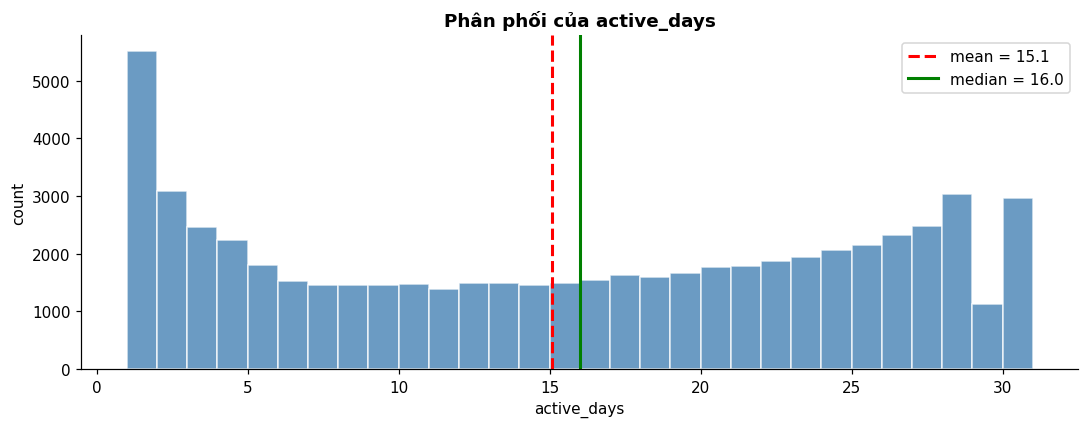

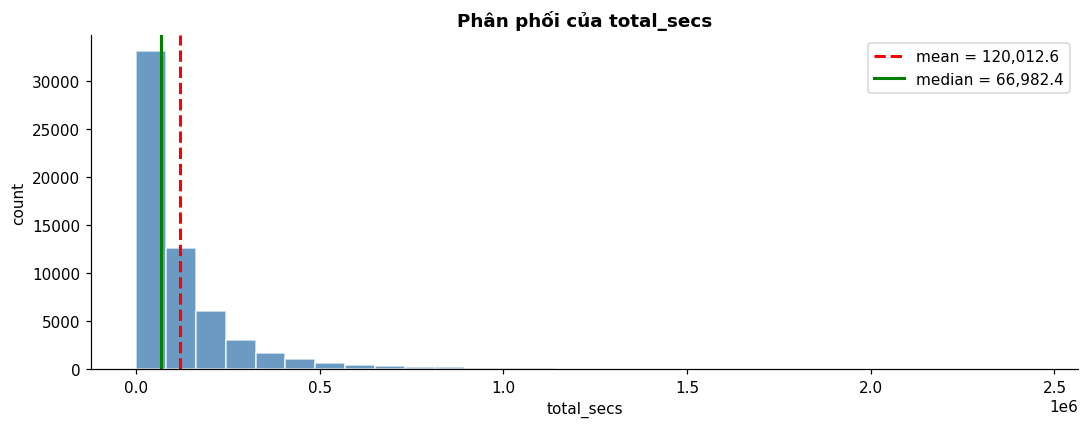

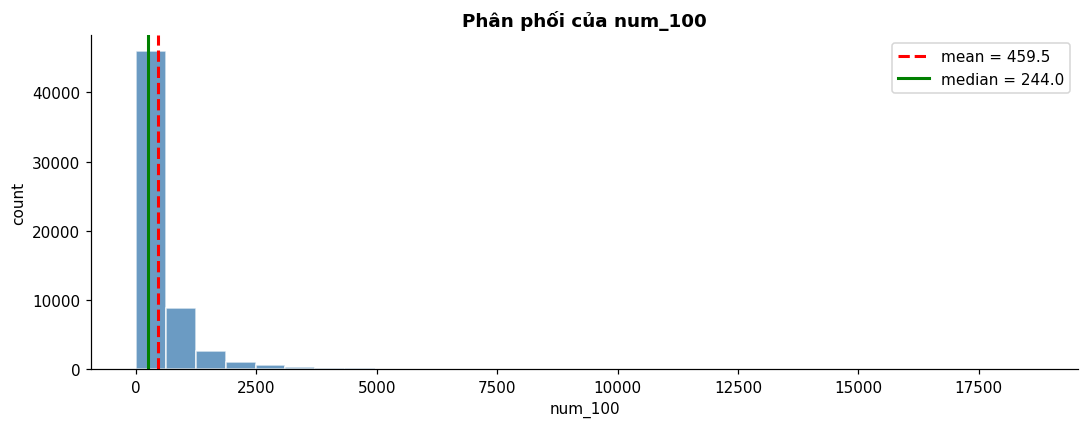

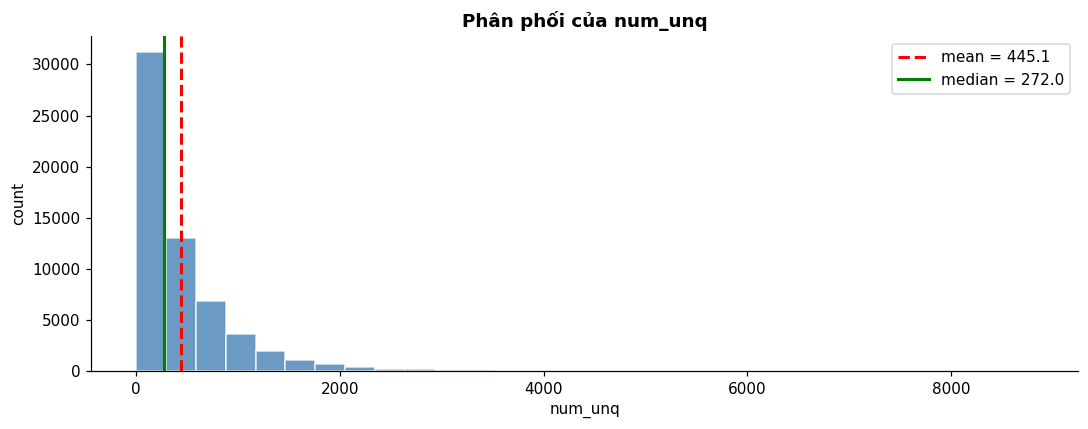

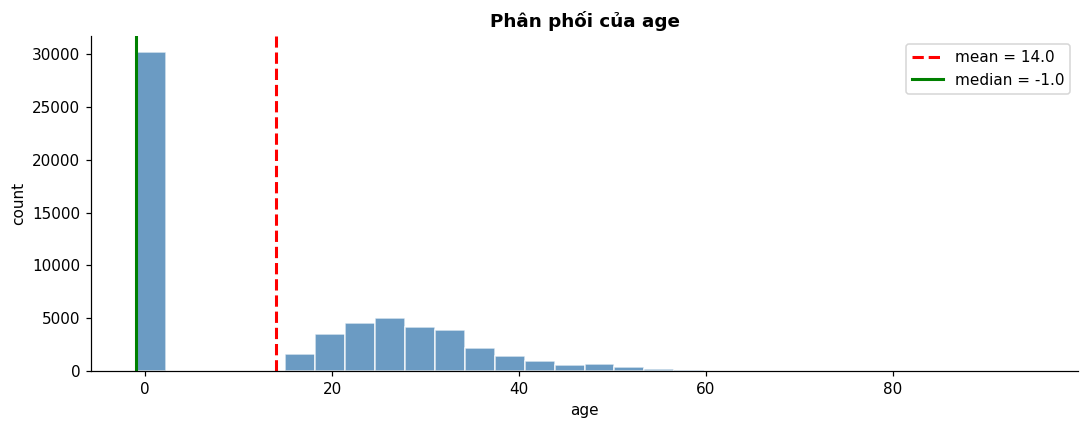

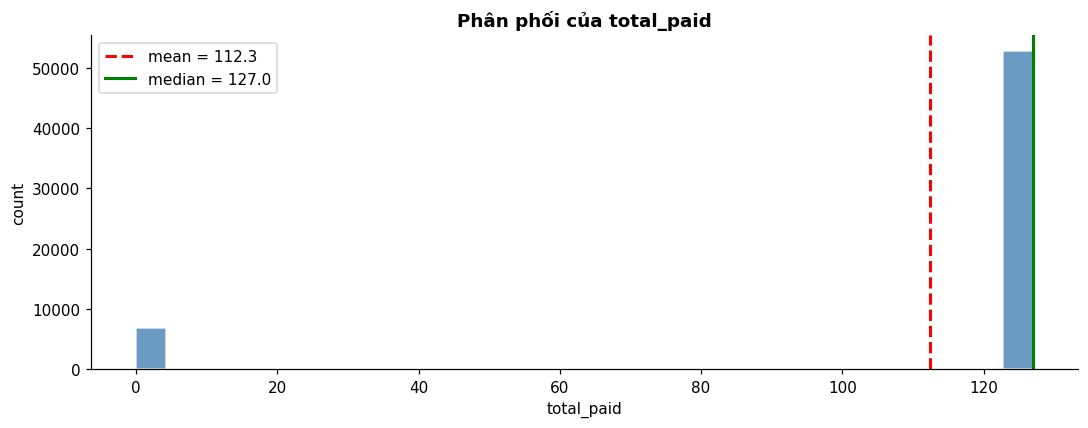

In [16]:
num_cols = ['active_days', 'total_secs', 'num_100', 'num_unq', 'age', 'total_paid']

for col in num_cols:
    try:
        plot_histogram(df_eda, col=col, title=f"Phân phối của {col}")
    except TypeError:
        plot_histogram(df_eda, cols=[col])

#print(outlier_summary(df_eda, num_cols))

So sánh số lượng các biến phân loại

In [14]:
df_eda['churn_label'] = df_eda['is_churn'].map({0: 'Non-Churn (0)', 1: 'Churn (1)'})

C:\Users\jason\AppData\Local\Temp\ipykernel_3080\3257217764.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_eda, x='is_churn', palette=['#2ecc71', '#e74c3c'])


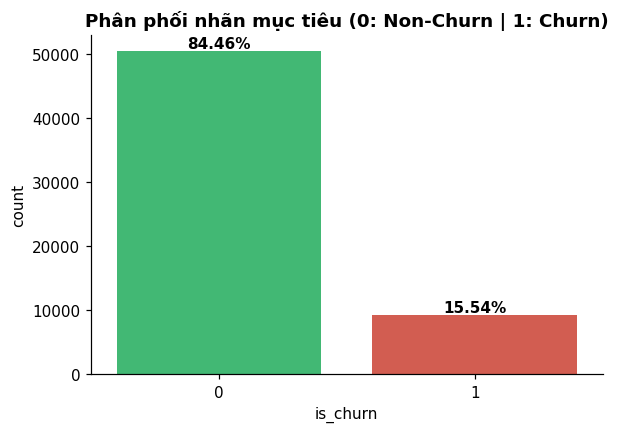

In [15]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_eda, x='is_churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Phân phối nhãn mục tiêu (0: Non-Churn | 1: Churn)')
for p in ax.patches:
    pct = 100 * p.get_height() / len(df_eda)
    ax.annotate(f'{pct:.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.show()

In [16]:
df_eda['has_auto_renew'] = np.where(df_eda['auto_renew_ratio'] > 0, 'Auto-Renew', 'No Auto-Renew')
df_eda['has_cancel'] = np.where(df_eda['cancel_count'] > 0, 'Cancelled', 'No Cancel')

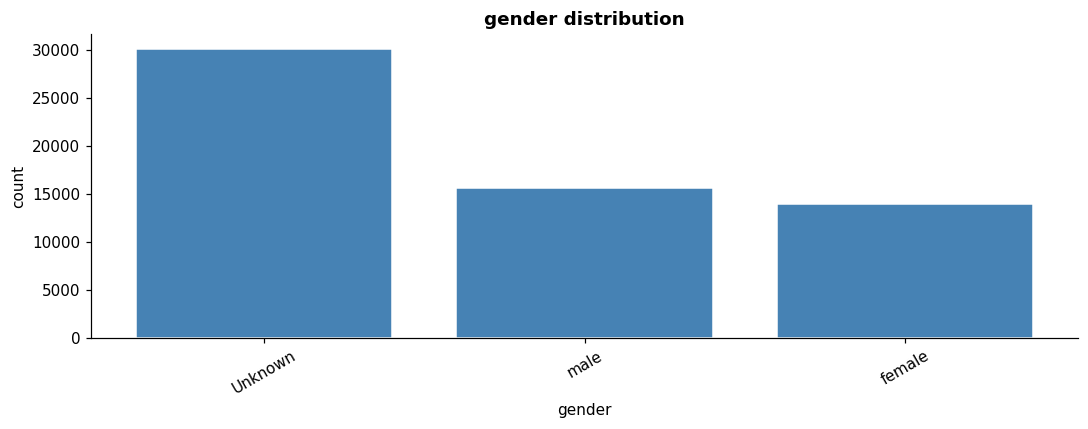

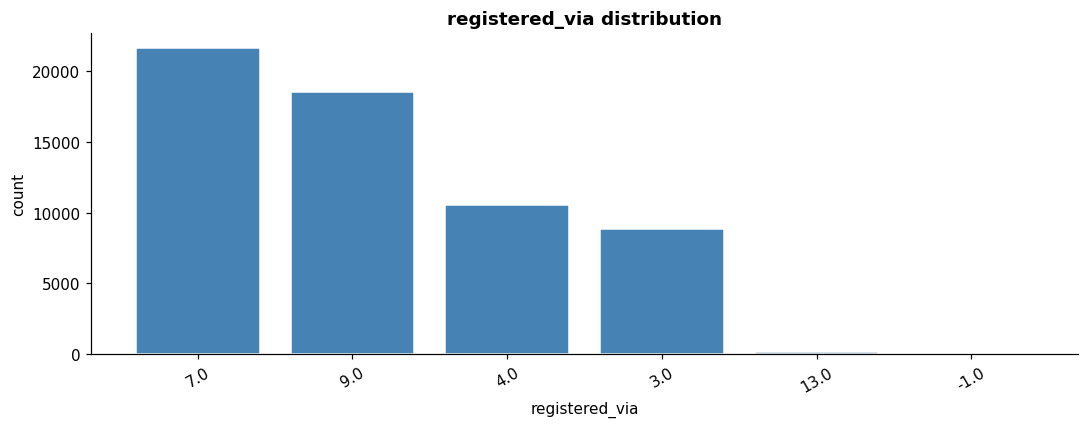

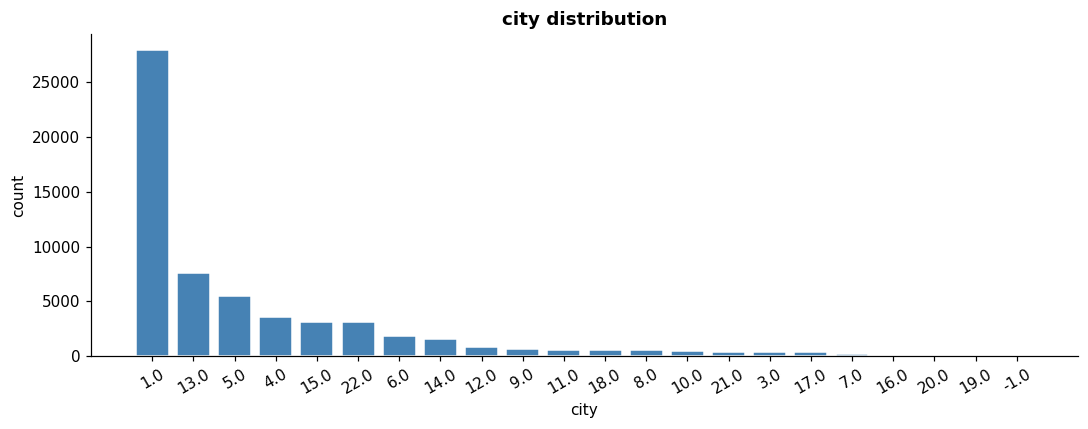

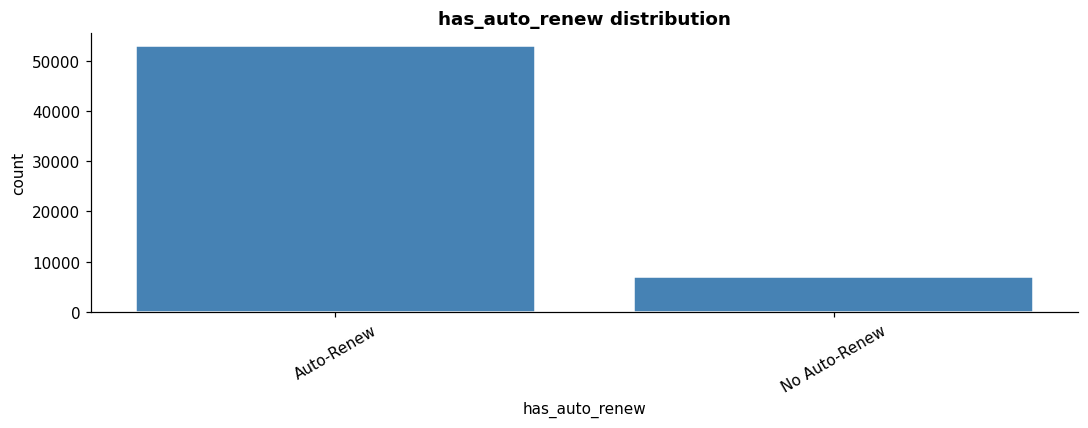

In [17]:
plot_countbar(df_eda, "gender")            # Phân bố giới tính
plot_countbar(df_eda, "registered_via")    # Kênh đăng ký
plot_countbar(df_eda, "city")              # Phân bố thành phố
plot_countbar(df_eda, "has_auto_renew")    # Tỷ lệ người dùng bật gia hạn tự động

# PHÂN TÍCH SONG BIẾN

Phân tích xu hướng thời lượng nghe theo ngày trong Tháng 2/2017

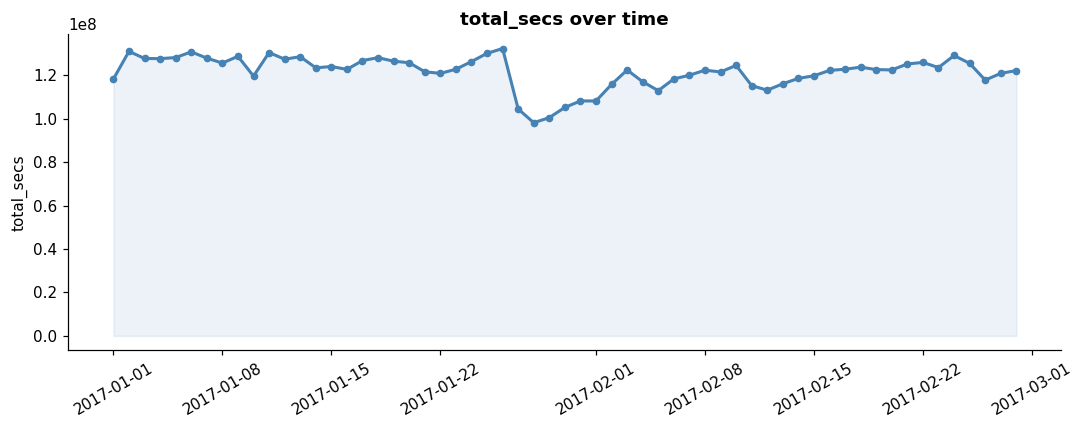

In [19]:
query_daily_wo = """
SELECT date, total_secs 
FROM fact_user_daily_activity 
WHERE date BETWEEN '2017-01-01' AND '2017-02-28'
"""
df_daily_wo = pd.read_sql(query_daily_wo, engine)
df_daily_wo['date'] = pd.to_datetime(df_daily_wo['date'])

# Gọi hàm plot_line giống trong file mẫu (freq="D" cho cấp độ ngày)
plot_line(df_daily_wo, 'date', 'total_secs', freq="D")

So sánh thời lượng nghe, số ngày hoạt động giữa nhóm Churn và Non-Churn

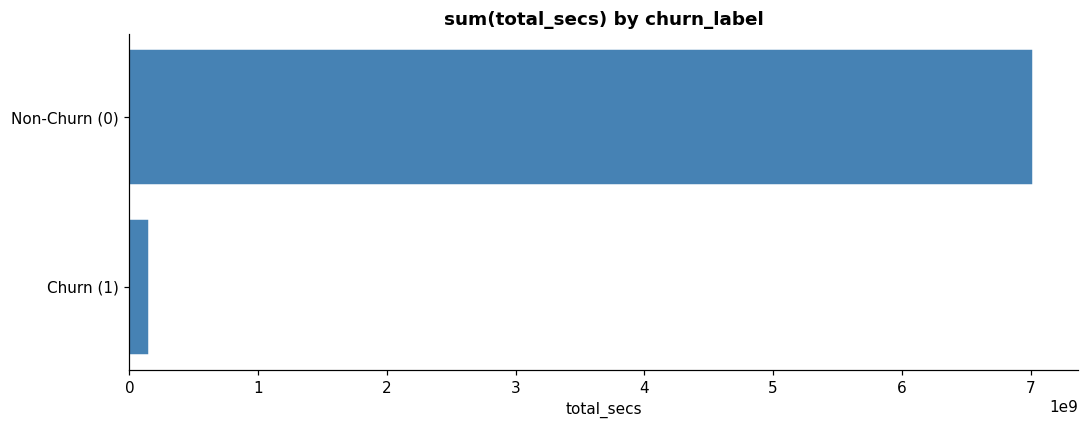

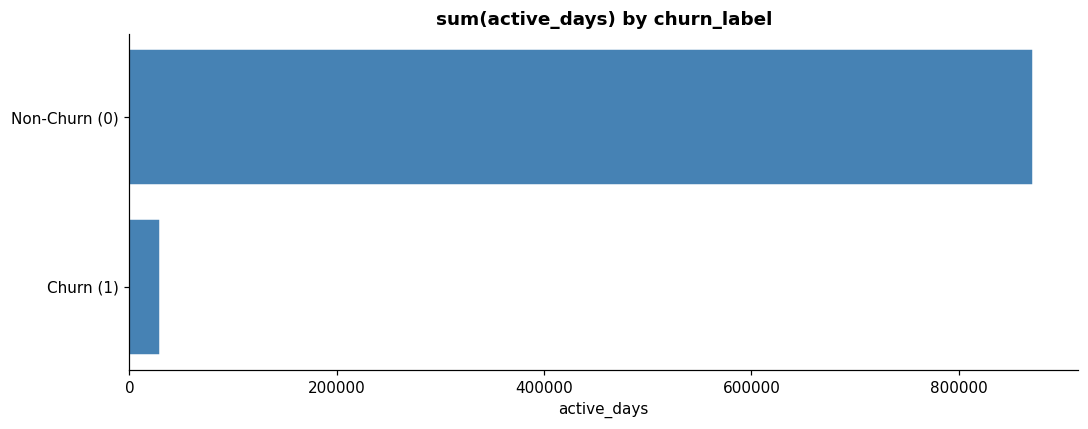

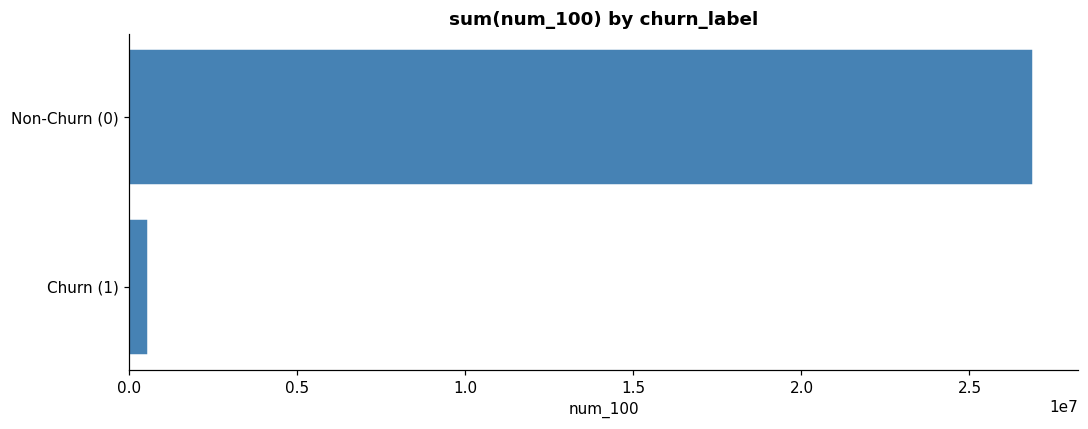

In [20]:
plot_bar(df_eda, "churn_label", "total_secs")
plot_bar(df_eda, "churn_label", "active_days")
plot_bar(df_eda, "churn_label", "num_100")

Phân tích tỷ lệ rời bỏ theo trạng thái Gia hạn tự động, Hủy gói và Kênh đăng ký

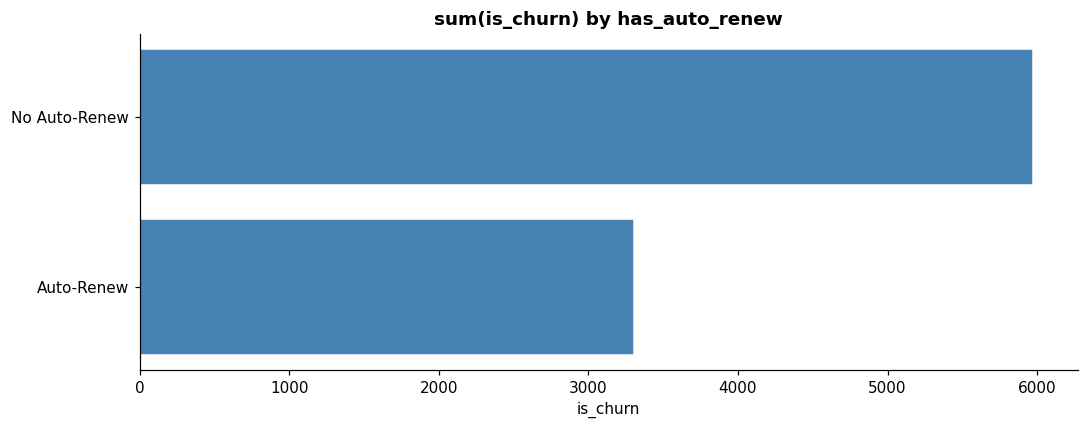

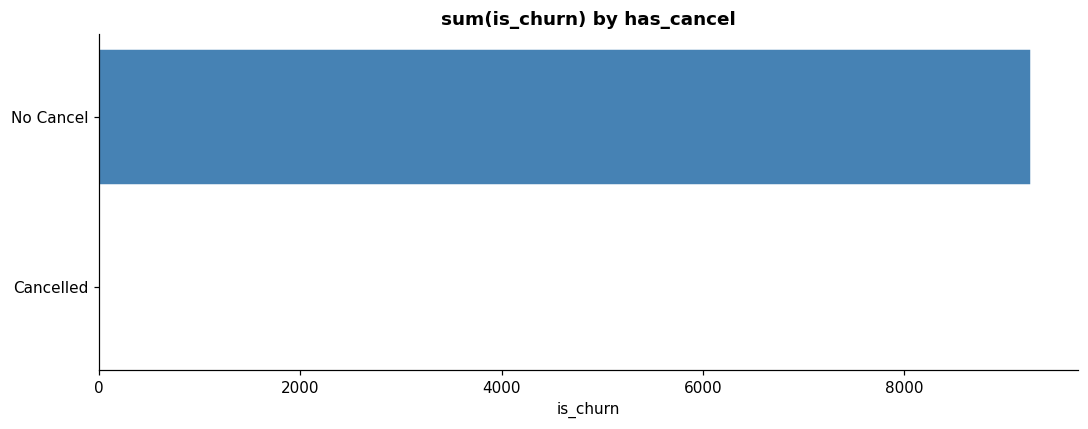

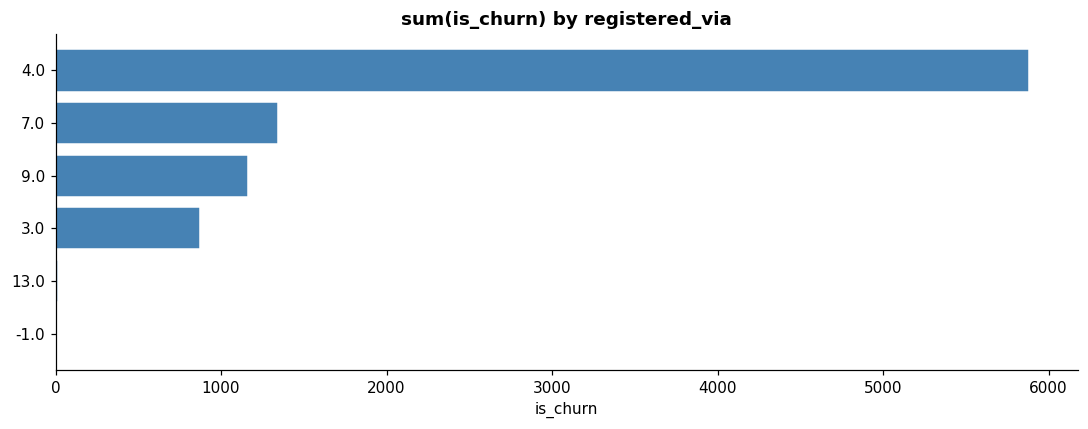

In [21]:
plot_bar(df_eda, "has_auto_renew", "is_churn")
plot_bar(df_eda, "has_cancel", "is_churn")
plot_bar(df_eda, "registered_via", "is_churn")

# PHÂN TÍCH ĐA BIẾN

Bảng KPI tổng hợp đa biến theo Nhãn Churn & Trạng thái Auto-Renew

In [22]:
churn_behavior_kpi = df_eda.groupby(["churn_label", "has_auto_renew"]).agg(
    totalCustomer=("msno", "nunique"),
    avgActiveDays=("active_days", "mean"),
    avgTotalSecs=("total_secs", "mean"),
    avgCompletedSongs=("num_100", "mean"),
    avgTotalPaid=("total_paid", "mean")
).reset_index()

display(churn_behavior_kpi)

,churn_label,has_auto_renew,totalCustomer,avgActiveDays,avgTotalSecs,avgCompletedSongs,avgTotalPaid
0,Churn (1),Auto-Renew,3306,5.061101,29053.664062,109.453117,0.571688
1,Churn (1),No Auto-Renew,5974,2.159859,8837.858398,31.397890,0.000000
2,Non-Churn (0),Auto-Renew,25985,17.500111,140925.359375,539.964600,0.670578
3,Non-Churn (0),No Auto-Renew,818,5.383188,42999.867188,164.946503,0.000000


Tính tỷ lệ thay đổi thời lượng nghe nửa cuối tháng 2 (15-28/02) so với nửa đầu tháng 2 (01-14/02)

In [23]:
df_eda['decay_ratio'] = (df_eda['secs_second_half'] - df_eda['secs_first_half']) / (df_eda['secs_first_half'] + 1.0)
df_eda['skip_ratio'] = df_eda['num_25'] / (df_eda['num_100'] + df_eda['num_25'] + 1.0)

decay_kpi = df_eda.groupby("churn_label").agg(
    avgSecsFirstHalf=("secs_first_half", "mean"),
    avgSecsSecondHalf=("secs_second_half", "mean"),
    avgDecayRatio=("decay_ratio", "mean"),
    avgSkipRatio=("skip_ratio", "mean")
).reset_index()

display(decay_kpi)

,churn_label,avgSecsFirstHalf,avgSecsSecondHalf,avgDecayRatio,avgSkipRatio
0,Churn (1),10583.463867,5456.276855,2549.528809,0.344275
1,Non-Churn (0),68323.421875,70823.140625,1608.251953,0.215721


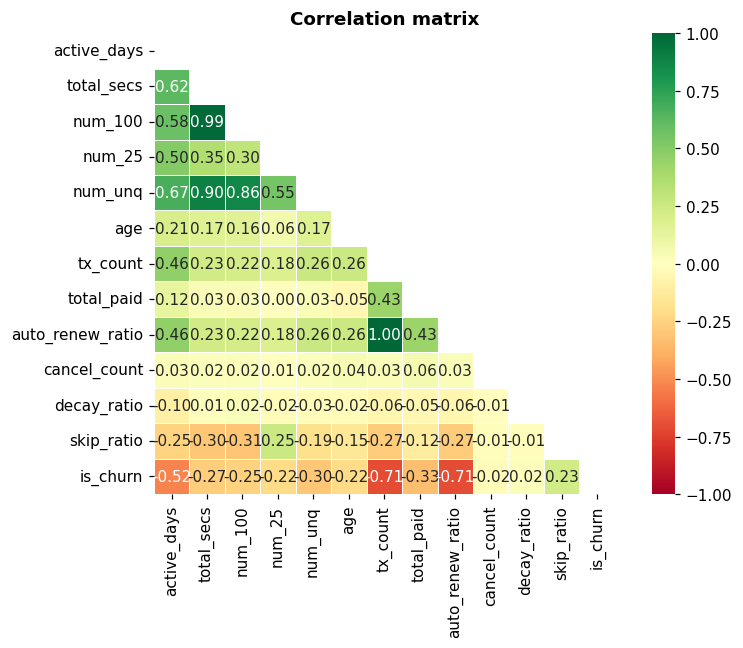

In [24]:
corr_cols = [
    'active_days', 'total_secs', 'num_100', 'num_25', 'num_unq',
    'age', 'tx_count', 'total_paid', 'auto_renew_ratio', 'cancel_count', 'decay_ratio', 'skip_ratio', 'is_churn'
]

# Sử dụng hàm có sẵn trong utils.visual (hoặc seaborn heatmap)
plot_heatmap_corr(df_eda, cols=corr_cols)

# OUTLIER

In [25]:
master_numeric_cols = [
    'active_days', 
    'total_secs', 
    'num_100', 
    'num_unq', 
    'total_paid', 
    'tx_count', 
    'cancel_count',
    'decay_ratio',
    'skip_ratio',
    'age'
]

data_outlier = df_eda[master_numeric_cols].dropna()

In [26]:
Q1 = data_outlier.quantile(0.25)
Q3 = data_outlier.quantile(0.75)
print(f"Q1: \n{Q1}, \nQ3: \n{Q3}")

Q1: 
active_days         5.000000
total_secs      18232.175781
num_100            63.000000
num_unq            77.000000
total_paid          0.000000
tx_count            1.000000
cancel_count        0.000000
decay_ratio        -0.460687
skip_ratio          0.084428
age                -1.000000
Name: 0.25, dtype: float64, 
Q3: 
active_days         24.000000
total_secs      154003.328125
num_100            578.000000
num_unq            603.000000
total_paid           1.000000
tx_count             1.000000
cancel_count         0.000000
decay_ratio          0.992738
skip_ratio           0.333333
age                 27.000000
Name: 0.75, dtype: float64


In [27]:
for col in master_numeric_cols:
    s = data_outlier[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, up = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    
    n_low = (s < low).sum()
    n_high = (s > up).sum()
    n_out = n_low + n_high
    pct = (n_out / len(s)) * 100
    
    print(f"{col:<15} | Outliers: {n_out:>7,} ({pct:5.2f}%) | Lower: {n_low:>6,} | Upper: {n_high:>7,}")

active_days     | Outliers:       0 ( 0.00%) | Lower:      0 | Upper:       0
total_secs      | Outliers:   4,134 ( 6.92%) | Lower:      0 | Upper:   4,134
num_100         | Outliers:   4,239 ( 7.10%) | Lower:      0 | Upper:   4,239
num_unq         | Outliers:   3,445 ( 5.77%) | Lower:      0 | Upper:   3,445
total_paid      | Outliers:       0 ( 0.00%) | Lower:      0 | Upper:       0
tx_count        | Outliers:   6,890 (11.54%) | Lower:  6,890 | Upper:       0
cancel_count    | Outliers:     309 ( 0.52%) | Lower:      0 | Upper:     309
decay_ratio     | Outliers:   9,411 (15.76%) | Lower:      0 | Upper:   9,411
skip_ratio      | Outliers:   2,402 ( 4.02%) | Lower:      0 | Upper:   2,402
age             | Outliers:      38 ( 0.06%) | Lower:      0 | Upper:      38


In [28]:
print(outlier_summary(data_outlier, master_numeric_cols))

column                      lower      upper    n_out    pct
------------------------------------------------------------
active_days                 -23.5       52.5        0   0.0%
total_secs             -185,424.6  357,660.1    4,134   6.9%
num_100                    -709.5    1,350.5    4,239   7.1%
num_unq                    -712.0    1,392.0    3,445   5.8%
total_paid                   -1.5        2.5        0   0.0%
tx_count                      1.0        1.0    6,890  11.5%
cancel_count                  0.0        0.0      309   0.5%
decay_ratio                  -2.6        3.2    9,411  15.8%
skip_ratio                   -0.3        0.7    2,402   4.0%
age                         -43.0       69.0       38   0.1%
None


In [29]:
df_eda.to_pickle('master_eda.pkl')